# 01 - Data Preparation: South German Credit Dataset

Welcome! This notebook guides you through the first step of a fairness-aware credit modeling workflow: data preparation. We will:
- Load and inspect the raw dataset
- Translate column names from German to English
- Replace numeric codes with descriptive labels
- Perform basic exploratory analysis

**Checklist:**
- [x] Load data
- [x] Translate columns
- [x] Map codes to labels
- [ ] Explore distributions
- [ ] Save clean data for next steps

Let's get started!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# Load Dataset
df = pd.read_csv('./../data/SouthGermanCredit.asc', delimiter=' ')

## 2. Coluns Translation from German to English

In [2]:
df.columns

Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='object')

In [3]:
# Assign English column names
df.columns = [
    "checking_account_status", "duration_months", "credit_history", "purpose", "credit_amount",
    "savings_account_balance", "employment_duration", "installment_rate", "personal_status_sex",
    "guarantors", "residence_since", "property", "age", "other_installment_plans", "housing",
    "existing_credits_count", "job", "dependents", "telephone", "foreign_worker", "credit_risk"
]
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_balance,employment_duration,installment_rate,personal_status_sex,guarantors,...,property,age,other_installment_plans,housing,existing_credits_count,job,dependents,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


## 3. Replace numeric codes with descriptive labels based on codetable

In [4]:
df['checking_account_status'] = df['checking_account_status'].map({
    1: 'no checking account', 2: '< 0 DM', 3: '0 <= ... < 200 DM', 4: '>= 200 DM or salary ≥1yr'
})
df['credit_history'] = df['credit_history'].map({
    0: 'delay in past payments', 1: 'critical/other credits', 2: 'no credits taken/all paid duly',
    3: 'existing credits paid duly', 4: 'all credits at bank paid duly'
})
df['purpose'] = df['purpose'].map({
    0: 'others', 1: 'car (new)', 2: 'car (used)', 3: 'furniture/equipment', 4: 'radio/TV',
    5: 'appliances', 6: 'repairs', 7: 'education', 8: 'vacation', 9: 'retraining', 10: 'business'
})
df['savings_account_balance'] = df['savings_account_balance'].map({
    1: 'no savings', 2: '< 100 DM', 3: '100-500 DM', 4: '500-1000 DM', 5: '>= 1000 DM'
})
df['employment_duration'] = df['employment_duration'].map({
    1: 'unemployed', 2: '< 1 yr', 3: '1-4 yrs', 4: '4-7 yrs', 5: '>= 7 yrs'
})

df['personal_status_sex'] = df['personal_status_sex'].map({
    1: 'male: divorced/separated',
    2: 'female: non-single or male: single',
    3: 'male: married/widowed',
    4: 'female: single'
})

df['guarantors'] = df['guarantors'].map({1: 'none', 2: 'co-applicant', 3: 'guarantor'})
df['property'] = df['property'].map({
    1: 'unknown/no property', 2: 'car/other', 3: 'insurance/savings', 4: 'real estate'
})
df['other_installment_plans'] = df['other_installment_plans'].map({1: 'bank', 2: 'stores', 3: 'none'})
df['housing'] = df['housing'].map({1: 'for free', 2: 'rent', 3: 'own'})
df['job'] = df['job'].map({
    1: 'unemployed/unskilled-nonresident', 2: 'unskilled-resident',
    3: 'skilled employee', 4: 'manager/self-employed/highly qualified'
})
df['dependents'] = df['dependents'].map({1: '3 or more', 2: '0 to 2'})
df['telephone'] = df['telephone'].map({1: 'no', 2: 'yes'})
df['foreign_worker'] = df['foreign_worker'].map({1: 'yes', 2: 'no'})
df['credit_risk'] = df['credit_risk'].map({1: 'good', 0: 'bad'})

df['installment_rate'] = df['installment_rate'].map({1: '>=35', 2: '25<= ... < 35', 3:'20<= ... > 25', 4: '<20'})
df['residence_since'] = df['residence_since'].map({1: '< 1yr', 2: '1 <= ... < 4 yrs', 3:'4 <= ... < 7 yrs', 4: '>= 7 yrs'})
df['existing_credits_count'] = df['existing_credits_count'].map({1: '1', 2: '2-3', 3:'4-5', 4: '>= 6'})


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account_status  1000 non-null   object
 1   duration_months          1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account_balance  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   object
 8   personal_status_sex      1000 non-null   object
 9   guarantors               1000 non-null   object
 10  residence_since          1000 non-null   object
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

## 4. Exploratory Data Analysis (EDA)
Target variable distribution (credit_risk)

Sensitive variables distribution

Análise de correlação entre variáveis

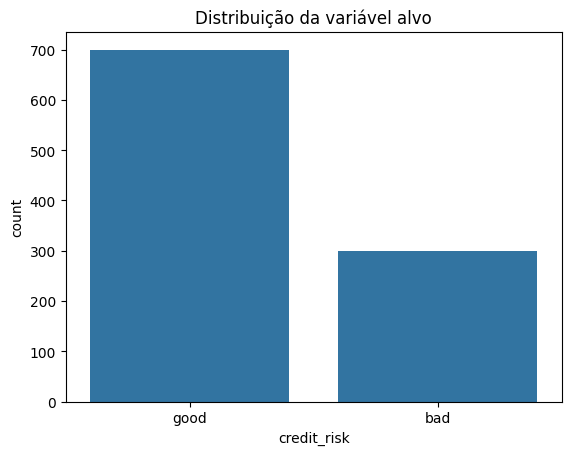

In [6]:
# Exemplo: distribuição da variável alvo
sns.countplot(x='credit_risk', data=df)
plt.title('Distribuição da variável alvo')
plt.show()


In [7]:

profile = ProfileReport(df, title="Profiling Report",explorative=True)
profile.to_file("./../reports/raw_data.html")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 2510.49it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Check for missing values and class distribution
print(df.isnull().sum())
df['credit_risk'].value_counts(normalize=True)

checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account_balance    0
employment_duration        0
installment_rate           0
personal_status_sex        0
guarantors                 0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits_count     0
job                        0
dependents                 0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64


credit_risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

In [9]:
df.to_parquet('./../data/silver/SouthGermanCredit_en.parquet', index=False)

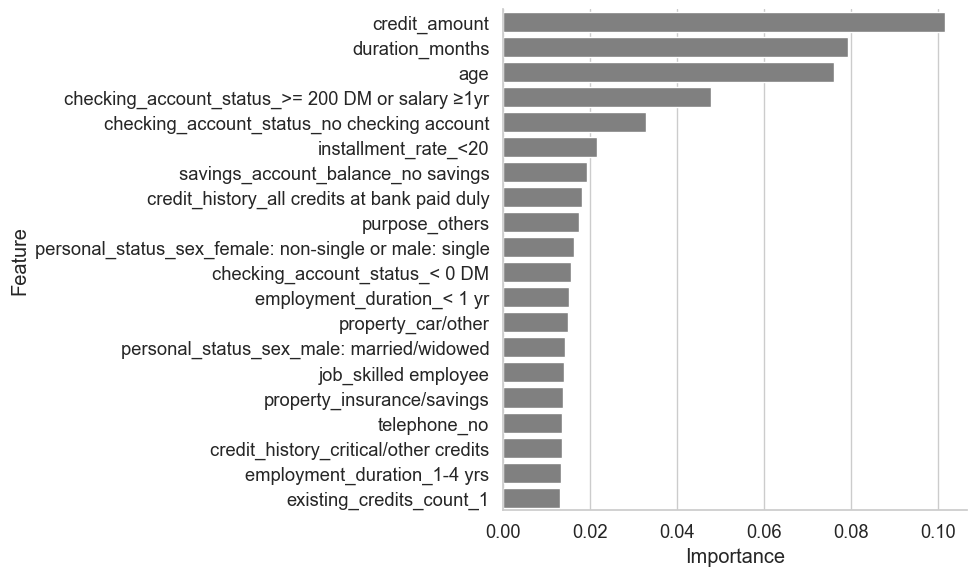

In [17]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume df is your cleaned DataFrame
# Replace 'credit_risk' with the actual target column
target = 'credit_risk'
X = df.drop(columns=[target])
y = df[target]

# Separate column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing for numeric data
numeric_transformer = SimpleImputer(strategy='median')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)])

# Create pipeline
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
clf.fit(X_train, y_train)

# Get feature names after preprocessing
encoded_features = clf.named_steps['preprocessor'].transformers_[1][1]    .named_steps['onehot'].get_feature_names_out(categorical_cols)
feature_names = numerical_cols + list(encoded_features)

# Get feature importances
importances = clf.named_steps['classifier'].feature_importances_
feat_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='importance', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='importance', y='feature', color='gray')
plt.xlabel('Correlation (abs) or MI Score')
plt.ylabel('Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
sns.despine()
plt.tight_layout()
plt.show()
